In [1]:
import ChessLens

from matplotlib import pyplot as plt
import numpy as np
import cv2

import torch

from Dataset.DataSetLoaders.ChessDataset import ChessDataset

In [2]:
dataset = ChessDataset(
    config={
        "img_size": (640,640)
    }
)
dataloader = ChessDataset.getLoader(dataset, batch_size=4, num_worders=0)

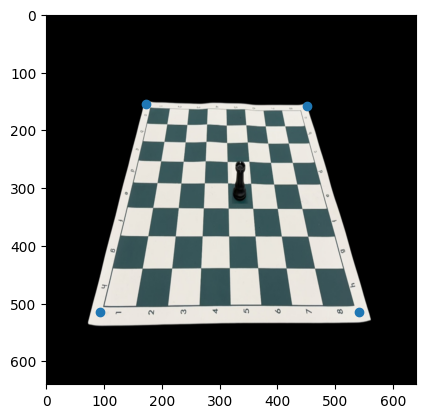

In [3]:
# for img, label in dataset:
    # _, H, W = img.shape
    # print(label)
    # plt.imshow(img.permute(1,2,0));
    # plt.scatter(label["corners"][:,0], label["corners"][:,1])

    # print(H, W)
    # break

# img, _ = dataset[50]
# img, _ = dataset[278]

# img = ChessLens.ChessLensImage("/home/mostafaelfaggal/Downloads/WhatsApp Image 2025-11-26 at 8.37.43 PM.jpeg")
img = ChessLens.ChessLensImage("/home/mostafaelfaggal/Downloads/WhatsApp Image 2025-11-27 at 3.49.10 AM.jpeg")
# img = ChessLens.ChessLensImage(img, "yolo")
img.detect_board()
_, H, W = img.img.shape
label = {
    "corners": img.board_detection
}

plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);

In [4]:
s = 0
cx = W/2
cy = H/2

In [5]:
# fx = 2739.79 * 640 / 2304
# fy = 2739.79 * 640/1728
fx = 2739.79 * W/4032
fy = 2739.79 * H/3024

K = np.array([
    [fx, s, cx],
    [0, fy, cy],
    [0,  0,  1]
]) # K: intrinsics of 3d -> 2d

In [6]:
cam_point = np.array([0,0,.5])
Z = cam_point[2]

def extrinsics_from_planar_points(image_pts, K, L=1.0):
    """
    image_pts: (4,2) image coordinates in pixels, in known order (clockwise or ccw)
    K: 3x3 camera intrinsics
    L: side length of the square in world coordinates (any unit)
    Returns:
        R: 3x3 rotation matrix (world→camera)
        t: 3x1 translation vector (world→camera)
        H: 3x3 homography (plane→image)
    """
    # Define square points on the world plane Z=0
    world_pts = np.array([
        [0, 0],
        [L, 0],
        [L, L],
        [0, L]
    ], dtype=np.float64)

    # Find homography (plane -> image)
    H, _ = cv2.findHomography(world_pts, image_pts)

    # Decompose using intrinsics
    K_inv = np.linalg.inv(K)
    h1, h2, h3 = H[:,0], H[:,1], H[:,2]

    # Normalize rotation columns
    lam = 1.0 / np.linalg.norm(K_inv @ h1)
    r1 = lam * (K_inv @ h1)
    r2 = lam * (K_inv @ h2)
    r3 = np.cross(r1, r2)

    R = np.column_stack((r1, r2, r3))
    # Enforce orthonormality via SVD
    U, _, Vt = np.linalg.svd(R)
    R = U @ Vt

    # Ensure a right-handed coordinate system
    if np.linalg.det(R) < 0:
        R[:, 2] *= -1

    t = lam * (K_inv @ h3)
    return R, t.reshape(3,1), H


# r_val = 1/np.sqrt(2)
# R_ = np.array([
#     [1, 0, 0],
#     [0, -r_val, -r_val],
#     [0, r_val, -r_val],
# ])

R_, t, H = extrinsics_from_planar_points(img.board_detection.numpy(), K, 1)
pitch = np.degrees(np.arctan2(R_[2,1], R_[1,1]))
print(pitch)

t = (-R_) @ cam_point.reshape((3,1))
# t = np.array([
#     [0],
#     [-Z * r_val],
#     [Z * r_val]
# ])

R = np.concat([R_, t], axis=1)
R = np.concat([R, np.array([[0,0,0,1]])], axis=0) # R: extrinsics of World -> Camera

-37.53038308437345


In [7]:
def from_3d_to_2d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ R.T
    res_points = (res_points / res_points[:,[3]])[:, :3]
    res_points = res_points @ K.T
    res_points = (res_points/res_points[:, [2]])[:, :2]
    return res_points

def from_2d_to_3d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(K).T

    points_ = np.concat([res_points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(R).T
    res_points = (res_points/res_points[:, [3]])[:, :3]

    return res_points

def trace_ray(directions: np.ndarray, cam_point: np.ndarray, Z_0: np.ndarray):
    N = directions.shape[0]
    if directions.shape[1] != 3 or len(directions.shape) != 2 \
        or cam_point.shape[0] != 3 or len(cam_point.shape) != 1 \
        or Z_0.shape[0] != N or len(Z_0.shape) != 1:
        raise Exception("Invalid input")
    
    t = ((Z_0-cam_point[2]) / (directions[:, 2] - cam_point[2]))
    p = cam_point + t.reshape(N, 1) * (directions - cam_point.reshape(1,3))
    return p

p = np.array([
    [1,2,3],
    [4,5,10]
])
print(p)
p1 = from_3d_to_2d(p, K, R)
print(p1)
p2 = from_2d_to_3d(p1, K, R)
print(p2)
p3 = trace_ray(p2, cam_point, np.array([3, 10]))
print(p3)

[[ 1  2  3]
 [ 4  5 10]]
[[     873.65      2618.5]
 [     696.41        1557]]
[[     1.2766      2.5531      3.6914]
 [    0.87636      1.0955      2.5814]]
[[          1           2           3]
 [          4           5          10]]


In [8]:
label["corners"]

tensor([[172., 155.],
        [451., 158.],
        [541., 515.],
        [ 93., 515.]])

In [9]:
corners_3d = trace_ray(from_2d_to_3d(label["corners"].numpy(), K, R), cam_point, np.zeros((4)))
corners_3d

array([[    0.25617,     0.67307,           0],
       [   -0.26002,     0.66763,           0],
       [   -0.26546,     0.16891,           0],
       [    0.25073,     0.17435,           0]])

In [10]:
corners_up_2d = from_3d_to_2d(corners_3d, K, R)
corners_up_2d

array([[        172,         155],
       [        451,         158],
       [        541,         515],
       [         93,         515]])

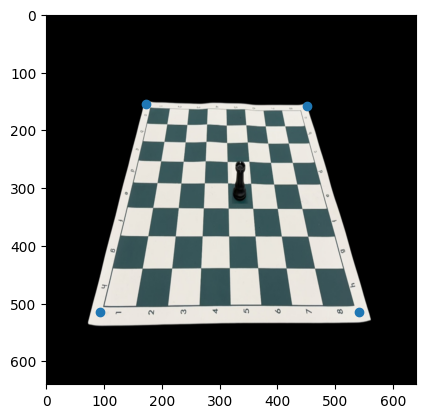

In [11]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(corners_up_2d[:,0], corners_up_2d[:,1]);

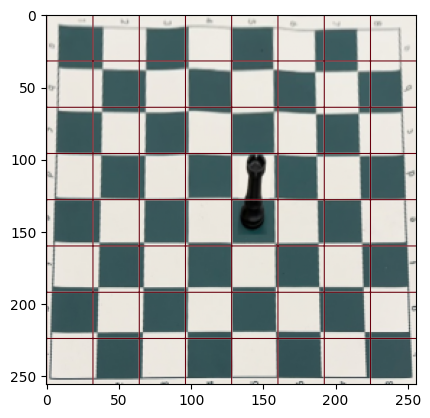

In [12]:
dst = np.array([
    [0,0],
    [256,0],
    [256,256],
    [0,256],
], dtype=np.float32)
pad = (0,0)
dst[:,0] += pad[0]
dst[:,1] += pad[1]

M = cv2.getPerspectiveTransform(img.board_detection.cpu().numpy().astype(np.float32), dst)
M = torch.tensor(M)

warpped_img = cv2.warpPerspective(img.img.permute(1,2,0).numpy(), M.numpy(), (256+2*pad[0],256+2*pad[1]))
plt.imshow(warpped_img);

grid = np.zeros((256+2*pad[0],256+2*pad[1]))
grid[::32, :] = 1
grid[:, ::32] = 1
plt.imshow(grid, alpha = grid, cmap="Reds");

In [46]:
r = 5
c = 5

In [47]:
sq_box = np.array([
    [(c-1)*32, (r-1)*32],
    [(c)*32, (r-1)*32],
    [(c)*32, (r)*32],
    [(c-1)*32, (r)*32],
], dtype=np.float32)

In [48]:
M_inv = np.linalg.inv(M)

inverted_sq = []

for i in range(len(sq_box)):
    inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))
    inverted_sq[-1] = (inverted_sq[-1] / inverted_sq[-1][2])[:2]

inverted_sq = np.stack(inverted_sq, axis=0)
inverted_sq

/tmp/ipykernel_498050/1142479384.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))


array([[     314.55,      294.07],
       [     357.47,      294.36],
       [     360.92,      339.32],
       [     315.35,      339.08]])

In [65]:
height = 0.1
pts = trace_ray(from_2d_to_3d(inverted_sq, K, R), cam_point, np.zeros(4)) + np.concat([np.zeros((4,2)), height*np.ones((4,1))], axis=1)
pts2 = from_3d_to_2d(pts, K, R)

In [66]:
points = np.concat([pts2, inverted_sq], axis=0).astype(np.int32)

# Get convex hull
hull = cv2.convexHull(points)

# Create empty mask
mask = np.zeros(img.img.shape[1:], dtype=np.uint8)

# Draw filled convex hull
cv2.drawContours(mask, [hull], 0, 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(640, 640), dtype=uint8)

(640, 640, 3)


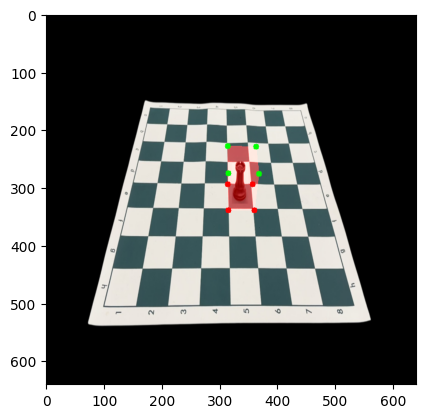

In [67]:
# plt.imshow(img.img.permute(1,2,0));
# plt.scatter(inverted_sq[:,0], inverted_sq[:,1]);
# plt.scatter(pts2[:,0], pts2[:,1]);

# plt.imshow(mask, alpha=(mask/255)*.35, cmap='Reds');

alpha = 0.55
mask_norm = mask.astype(np.float32) / 255

img_np = (img.img.clone().detach().permute(1,2,0).numpy()*255).astype(np.uint8)
red_overlay = np.zeros_like(img_np, dtype=np.uint8)
red_overlay[:,:,0] = 255

# img_final = img_np.copy()
# img_final[:,:,0] += (red_overlay[:,:,0] * alpha * mask_norm).astype(np.uint8)
# img_final = np.clip(img_final, 0, 255)

red_with_mask = (red_overlay * mask_norm[:,:,None]).astype(np.uint8)
img_final = cv2.addWeighted(img_np, 1, red_with_mask, alpha, 0).astype(np.uint8)
# img_final = img_np
# img_final = (img_final * 255).astype(np.uint8) if img_final.max() <= 1 else img_final.astype(np.uint8)

# print(type(img_final), img_final.shape, img_final.dtype, img_final.max(), img_final.min())

for pt in inverted_sq:
    cv2.circle(img_final, tuple(map(int, pt)), 5, (255, 0, 0), -1)
for pt in pts2:
    cv2.circle(img_final, tuple(map(int, pt)), 5, (0, 255, 0), -1)

print(img_final.shape)

cv2.imwrite("output4.jpg", img_final[:,:,::-1])

plt.imshow(img_final);

In [68]:
xs = np.linspace(0,256, 9)
ys = np.linspace(0,256, 9)

X, Y = np.meshgrid(xs, ys)
points = np.stack([X,Y], axis=2)

points.shape, X.shape, Y.shape, points[3,6]

((9, 9, 2), (9, 9), (9, 9), array([        192,          96]))

In [69]:
tmp = np.concat([points, np.ones((9,9,1))], axis=2) @ M_inv.numpy().T

tmp = (tmp/tmp[:, :, [2]])[:, :, :2].reshape(-1, 2)
tmp

array([[        172,         155],
       [     207.13,      155.38],
       [     242.19,      155.75],
       [     277.17,      156.13],
       [     312.08,      156.51],
       [     346.92,      156.88],
       [     381.69,      157.25],
       [     416.38,      157.63],
       [        451,         158],
       [     165.56,      184.34],
       [     202.44,       184.7],
       [     239.25,      185.07],
       [     275.97,      185.43],
       [     312.61,      185.79],
       [     349.17,      186.15],
       [     385.65,      186.51],
       [     422.05,      186.87],
       [     458.37,      187.23],
       [     158.45,      216.75],
       [     197.27,      217.09],
       [        236,      217.44],
       [     274.64,      217.78],
       [     313.19,      218.12],
       [     351.65,      218.47],
       [     390.02,      218.81],
       [     428.31,      219.15],
       [      466.5,      219.49],
       [     150.55,      252.73],
       [     191.52,

In [70]:
elevated_tmp = trace_ray(from_2d_to_3d(tmp, K, R), cam_point, np.zeros((81)))
elevated_tmp += np.concat([np.zeros((81,2)), .1*np.ones((81, 1))], axis=1)
elevated_tmp = from_3d_to_2d(elevated_tmp, K, R)
elevated_tmp

array([[     156.53,       87.96],
       [     195.54,      88.457],
       [     234.45,      88.954],
       [     273.27,      89.448],
       [        312,      89.942],
       [     350.64,      90.435],
       [     389.19,      90.926],
       [     427.65,      91.417],
       [     466.03,      91.906],
       [     148.49,      116.98],
       [     189.67,      117.47],
       [     230.74,      117.96],
       [     271.71,      118.44],
       [     312.58,      118.93],
       [     353.35,      119.41],
       [     394.02,       119.9],
       [     434.59,      120.38],
       [     475.07,      120.86],
       [     139.51,      149.41],
       [     183.11,      149.88],
       [     226.59,      150.36],
       [     269.97,      150.83],
       [     313.23,       151.3],
       [     356.38,      151.77],
       [     399.41,      152.24],
       [     442.34,      152.71],
       [     485.16,      153.18],
       [      129.4,      185.88],
       [     175.73,

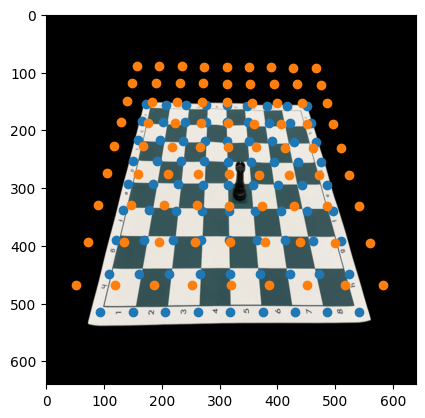

In [71]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(tmp[:,0], tmp[:,1]);
plt.scatter(elevated_tmp[:,0], elevated_tmp[:,1]);

(640, 640, 3) uint8


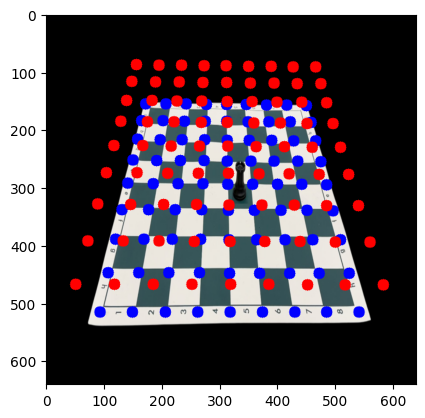

In [72]:
tmp_img = (img.img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
tmp_img = np.ascontiguousarray(tmp_img)
print(tmp_img.shape, tmp_img.dtype)
for x, y in tmp:
    tmp_img = cv2.circle(tmp_img, (int(x), int(y)), radius=10, color=(0,0,255), thickness=-1)
for x, y in elevated_tmp:
    tmp_img = cv2.circle(tmp_img, (int(x), int(y)), radius=10, color=(255,0,0), thickness=-1)

plt.imshow(torch.tensor(tmp_img));

In [73]:
res = torch.zeros(8, 8, sq_size[0], sq_size[1], 3)
for r in range(8):
    for c in range(8):
        # mask = np.zeros(self.img.shape[1:], dtype=np.uint8)

        square_top = grid_top[r:r+2, c:c+2]
        square_bottom = grid_bottom[r:r+2, c:c+2]
        crop_corners = torch.tensor([
            [square_top[:, :, 0].min(), square_top[:, :, 1].min()],
            [square_top[:, :, 0].max(), square_top[:, :, 1].min()],
            [square_bottom[:, :, 0].max(), square_bottom[:, :, 1].max()],
            [square_bottom[:, :, 0].min(), square_bottom[:, :, 1].max()],
        ]).numpy().astype(np.float32)

        dst_corners = np.array([
            [0, 0],
            [sq_size[1], 0],
            [sq_size[1], sq_size[0]],
            [0, sq_size[0]],
        ], dtype=np.float32)

        # if r == 5 and c == 2:
        #     plt.imshow(self.numpy_img)
        #     plt.scatter(square_top.reshape(-1, 2)
        #                 [:, 0], square_top.reshape(-1, 2)[:, 1])
        #     plt.scatter(square_bottom.reshape(-1, 2)
        #                 [:, 0], square_bottom.reshape(-1, 2)[:, 1])
        #     plt.scatter(crop_corners[:, 0], crop_corners[:, 1])

        #     raise Exception("stop")

        M_tmp = cv2.getPerspectiveTransform(crop_corners, dst_corners)
        # tmp_img = np.ascontiguousarray(self.numpy_img.copy())
        # for x, y in square_bottom.reshape(-1, 2):
        #     tmp_img = cv2.circle(tmp_img, (int(x), int(y)),
        #                          radius=6, color=(0, 0, 255), thickness=-1)
        # for x, y in square_top.reshape(-1, 2):
        #     tmp_img = cv2.circle(tmp_img, (int(x), int(y)),
        #                          radius=6, color=(255, 0, 0), thickness=-1)
        res[r, c] = torch.tensor(cv2.warpPerspective(
            self.numpy_img, M_tmp, (sq_size[1], sq_size[0])))
        # warped_corners = cv2.perspectiveTransform(np.concat(
        #     [square_bottom.reshape(-1, 2), square_top.reshape(-1, 2)], axis=0).reshape(-1, 1, 2), M_tmp).reshape(-1, 2)
        warped_corners = cv2.perspectiveTransform(
            square_bottom.reshape(-1, 1, 2), M_tmp).reshape(-1, 2)
        for x, y in warped_corners:
            lower_y, upper_y = int(max(y-5, 0)), int(min(y+5, 128))
            lower_x, upper_x = int(max(x-5, 0)), int(min(x+5, 64))
            res[r, c, lower_y:upper_y, lower_x:upper_x,
                :] = torch.tensor([0, 0, 255])
        # for x, y in warped_corners[4:]:
        #     lower_y, upper_y = int(max(y-5, 0)), int(min(y+5, 128))
        #     lower_x, upper_x = int(max(x-5, 0)), int(min(x+5, 64))
        #     res[r, c, lower_y:upper_y, lower_x:upper_x,
        #         :] = torch.tensor([255, 0, 0])

        # points = np.concat(
        #     [grid_bottom[r:r+2, c:c+2], grid_top[r:r+2, c:c+2]], axis=0).astype(np.int32).reshape(-1, 1, 2)
        # hull = cv2.convexHull(points)
        # # cv2.fillPoly(mask, hull, 255)
        # cv2.fillConvexPoly(mask, hull, 255)

        # x, y, w, h = cv2.boundingRect(points)
        # roi = self.numpy_img[y:y+h, x:x+w]
        # roi_mask = mask[y:y+h, x:x+w]

        # # roi_masked = cv2.bitwise_and(roi, roi, mask=roi_mask)
        # roi_masked = np.zeros_like(roi)
        # roi_masked = np.where(roi_mask[..., None], roi, roi_masked)

        # resized = cv2.resize(roi_masked, sq_size,
        #                      interpolation=cv2.INTER_AREA)

        # res[r, c] = torch.tensor(resized)
res = res.permute(0, 1, 4, 2, 3).to(torch.float32) / 255

end_time = time.perf_counter()
print(f"Preprocessing Step 2: {(end_time-start_time)*1e3:.6f} ms")

NameError: name 'sq_size' is not defined